In [1]:
import os.path
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import skimage as skimg
from PIL import Image

plt.rc('image', cmap='gray')
plt.rc('figure', autolayout=True)

In [2]:
#get image
image_path = "astronaut.jpg"
if not os.path.isfile(image_path):
    print("Downloading astronaut image...")
    # Load astronaut image from skimage
    img = skimg.data.astronaut()
    Image.fromarray(img).save(image_path)
else:
    print("Astronaut image already exists.")

Astronaut image already exists.


Original Image Shape: (300, 300, 1)


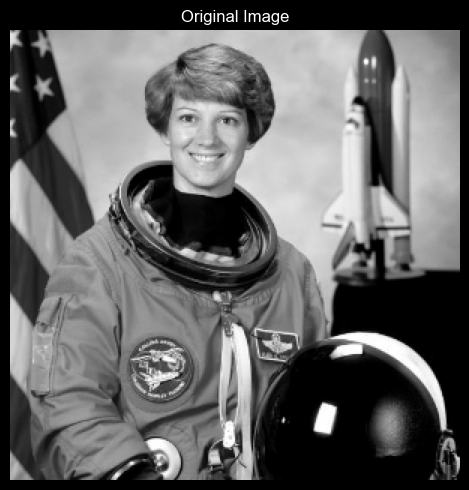

In [3]:
#load an image from skimage
image = tf.io.read_file(image_path)
image = tf.io.decode_jpeg(image, channels=1)
image = tf.image.resize(image, [300, 300])
image = tf.image.convert_image_dtype(image, tf.float32)

print("Original Image Shape:", image.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(image))
plt.title("Original Image")
plt.axis('off')
plt.show()

# Add batch dimension
image = tf.expand_dims(image, axis=0)

In [26]:
# Define convolutional kernel
kernel = tf.constant([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=tf.float32)

kernel = tf.reshape(kernel, [3, 3, 1, 1])
print("Kernel Shape:", kernel.shape)

Kernel Shape: (3, 3, 1, 1)


After Convolution Shape: (1, 300, 300, 1)


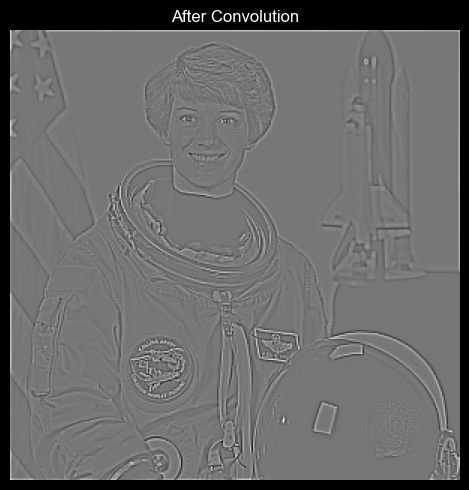

In [30]:
# Apply convolution layer
conv_output = tf.nn.conv2d(
    input=image,
    filters=kernel,
    strides=[1, 1, 1, 1],
    padding='SAME'
)

print("After Convolution Shape:", conv_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(conv_output))
plt.title("After Convolution")
plt.axis('off')
plt.show()

After ReLU Shape: (1, 300, 300, 1)


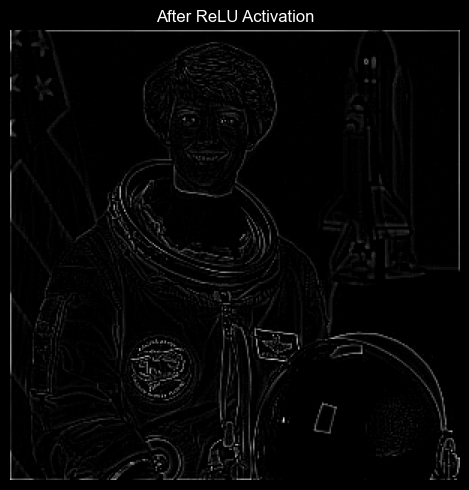

In [6]:
#apply ReLU Activation Function
relu_output = tf.nn.relu(conv_output)
sigmoid_output = tf.nn.sigmoid(conv_output)
tanh_output = tf.nn.tanh(conv_output)

print("After ReLU Shape:", relu_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(relu_output))
plt.title("After ReLU Activation")
plt.axis('off')
plt.show()

After Max Pooling Shape: (1, 150, 150, 1)


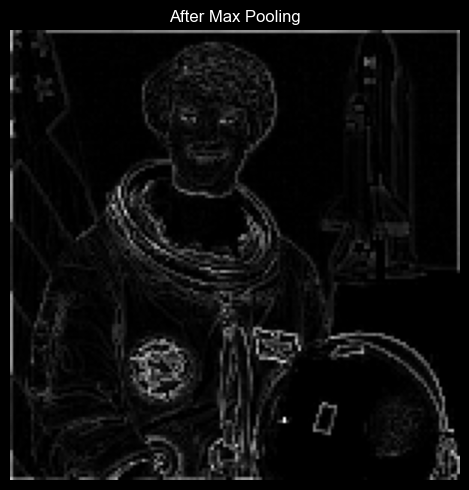

In [7]:
#apply Max Pooling
pool_output = tf.nn.max_pool2d(
    input=relu_output,
    ksize=2,
    strides=2,
    padding='SAME'
)
print("After Max Pooling Shape:", pool_output.shape)
plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(pool_output))
plt.title("After Max Pooling")
plt.axis('off')
plt.show()

After Average Pooling Shape: (1, 150, 150, 1)


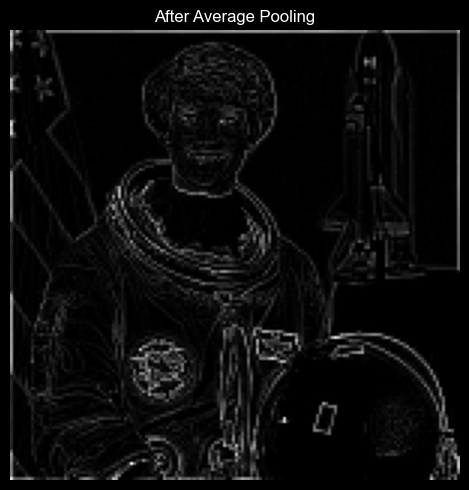

In [8]:
#apply Average Pooling
avg_pool_output = tf.nn.avg_pool2d(
    input=relu_output,
    ksize=2,
    strides=2,
    padding='SAME'
)
print("After Average Pooling Shape:", avg_pool_output.shape)
plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(avg_pool_output))
plt.title("After Average Pooling")
plt.axis('off')
plt.show()

In [9]:
#Apply Flattening Layer
flatten_layer = tf.keras.layers.Flatten()
flatten_output = flatten_layer(pool_output)

print("After Flatten Shape:", flatten_output.shape)

print("First 20 Flattened Values:")
print(flatten_output.numpy()[0][:20])

After Flatten Shape: (1, 22500)
First 20 Flattened Values:
[728.35016   245.28253   452.93674   337.2563      0.         14.2733345
  57.65235    62.57112    44.3565    177.0228    134.72699   180.97931
 479.44366   461.86447   484.1186    478.13367   486.00793   476.1836
 473.1297    479.70062  ]


In [10]:
#Add Fully Connected (Dense) Layer
dense_layer = tf.keras.layers.Dense(
    units=64,
    activation='relu'
)

dense_output = dense_layer(flatten_output)

print("After Fully Connected Layer Shape:", dense_output.shape)

After Fully Connected Layer Shape: (1, 64)


In [11]:
dense_output

<tf.Tensor: shape=(1, 64), dtype=float32, numpy=
array([[401.2573   ,   0.       , 109.369225 , 114.052345 ,   0.       ,
        405.38367  , 148.41173  , 100.98402  ,   0.       ,   0.       ,
        204.39857  ,   0.       ,   0.       ,   0.       ,  48.265797 ,
        175.91972  ,   0.       , 105.240776 ,  46.675247 ,   0.       ,
         25.80552  ,   0.       ,   0.       ,   0.       ,   0.       ,
          0.       ,   0.       ,   0.       ,   0.       ,   0.       ,
          0.       ,   0.       ,  99.06333  ,  46.64509  ,  99.93454  ,
          0.       ,   0.       ,   0.       , 172.5711   ,   0.       ,
          0.       , 260.60406  ,   0.       ,   0.       ,   0.       ,
        232.69513  ,   5.9428325, 139.42221  ,   0.       , 140.06444  ,
          0.       ,   0.       ,  40.045456 ,   0.       ,   0.       ,
          0.       ,   0.       ,  65.95273  ,   0.       ,   0.       ,
        167.69667  ,   0.       ,  29.835175 , 446.63766  ]],
      dtype=f